## A Hands-on Introduction to BioImage Simulation with DeepTrack2

Deep learning has a wide range of applications in microscopy: from locating synapses, to reconstructing trajectories from Single Particle Tracking (SPT) experiments, to cell counting. However, training such models to perform well on experimental setups usually requires collecting large amounts of data, which may be costly and not always available. Furthermore, it involves an annotation process that can be tedious and error-prone.

In this tutorial we will follow a different route: rather than annotating real images, we will simulate them. We will use [DeepTrack2](https://github.com/DeepTrackAI/DeepTrack2), an open-source library that uses physics-informed image simulation to generate labelled training data on demand, with known, exact ground truth and no manual annotation at all.

We will build the simulation step by step:
- Define a simple scatterer acting as a point particle and image it through a microscopy setup
- Add realistic sensor noise, and animate the particle with random motion such as Brownian dynamics
- Image the same object with different microscopy modalities
- Define more complicated objects, such as bacteria and cells
- Compose the full pipeline (scatterer → optics → noise) and use it to train a U-Net to count cells in a biological dataset (BBBC039)
- Evaluate the model on real images, and discuss which simulation choices matter most when moving from simulated to experimental data

### 0. Setup

If you are running on **Google Colab / Kaggle**, uncomment and run the next cell. Locally, install the packages once in your environment (`pip install deeptrack deeplay`).

In [ ]:
# !pip install deeptrack deeplay

In [ ]:
import os

import deeplay as dl
import deeptrack as dt
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import morphology as skmorph
import torch

/Users/guillem/miniforge3/envs/deeptrack2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Simulating images

Generating realistic synthetic images is an effective way to train and validate deep learning models for digital microscopy. In DeepTrack2, an image is built as a series of **features** applied in sequence. Each feature takes an input image and updates it according to an **update rule**: a feature can add a particle, image it through an optical device, or introduce noise.

#### 1.1 Point particle

We start with the simplest object: a point particle, i.e. an object smaller than the resolution of the microscope. This is the case of a diffraction-limited particle such as a single fluorophore. The code below creates one with the class `PointParticle` (a child of `Feature`), setting its properties `position` and `intensity`:

In [16]:
IMAGE_SIZE = 64

particle = dt.PointParticle(
    position=(IMAGE_SIZE//2, IMAGE_SIZE//2) * dt.units.pixel,
    intensity=40,
)

We use `dt.units.pixel` to state the unit of the property, although most of the time this can be omitted. Here we also choose the size of the image in pixels and place the particle in the center.

Once the object is defined, we need an optical device through which it is viewed to generate the image. In this case we define a fluorescence setup, choosing the numerical aperture (NA) of the objective, the wavelength of the emitted light, the magnification of the system, the pixel size of the camera (`resolution`), and and the output region (in pixels) of the generated image. These are the values of a 60x/1.4 oil-immersion objective and a typical sCMOS camera with 6.5 um pixels, which gives 6.5 / 60 = 108 nm per pixel in the sample:

In [17]:
fluorescence_microscope = dt.Fluorescence(
    NA=1.4,
    wavelength=680 * dt.units.nm,
    magnification=60,
    resolution=6.5 * dt.units.um,
    refractive_index_medium=1.518,  # Immersion oil.
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

By calling the fluorescence microscope `fluorescence_microscope` with the point particle `particle`, we create a new feature which resolves the image of the particle as seen through the fluorescence microscope:

<Axes: >

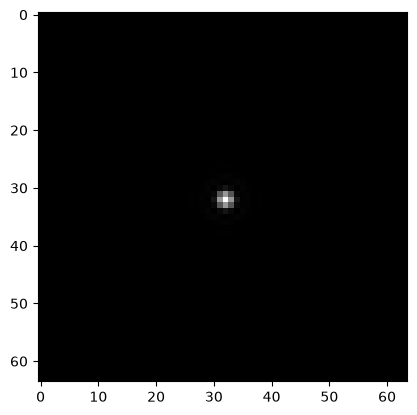

In [18]:
imaged_particle = fluorescence_microscope(particle)

imaged_particle.plot(cmap='grey')

So far `imaged_particle` is only a recipe. To get the actual image we resolve it, either by calling it or with the equivalent `.resolve()` method, which returns a NumPy array of shape `(height, width, channels)`:

Type: ndarray, shape: (64, 64, 1)


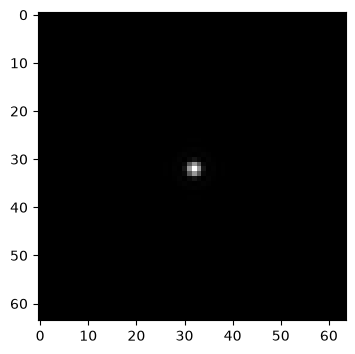

In [19]:
image = imaged_particle.resolve()  # Equivalent to imaged_particle().

print(f"Type: {type(image).__name__}, shape: {image.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(image[..., 0], cmap="gray")

#### 1.2 Multiple particles

Properties can also take **functions** instead of fixed values, which DeepTrack2 evaluates every time a new image is generated. Here we randomize the position, the intensity, and the depth `z` with respect to the focal plane:

In [20]:
particle = dt.PointParticle(
    position=lambda: np.random.uniform(4, IMAGE_SIZE-4, size=2),
    intensity=lambda: np.random.uniform(20, 60),
    z=lambda: np.random.uniform(-0.1, 0.1) * dt.units.um,
)

DeepTrack2 allows you to evaluate a feature multiple times using the `^` operator. Each time it is evaluated this way a new set of properties is used, which makes for a very convenient way to resolve multiple particles. We can use this to simulate a population of point emitters and image it through the fluorescent microscope:

<Axes: >

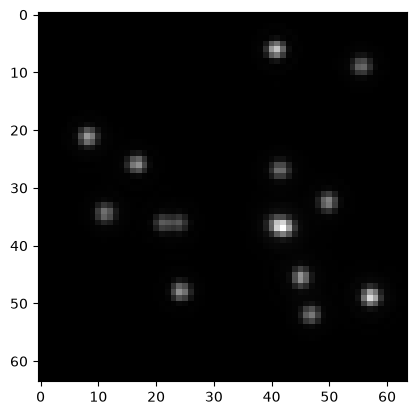

In [21]:
N_PARTICLES = 15

point_emitters = particle ^ N_PARTICLES

imaged_point_emitters = fluorescence_microscope(point_emitters)

imaged_point_emitters.plot(cmap="gray")

Re-running the cell gives the same image every time: the sampled values are stored as properties, since they are the ground truth of that image. If we want to resample the whole pipeline we can use the `.update()` method, e.g. `imaged_point_emitters.update().plot(cmap="gray")`.

#### 1.3 Adding noise

We now build our first **pipeline**, chaining features with the `>>` operator so that the output of each one becomes the input of the next. We use it to add noise to the image.

Real images are noisy, and in fluorescence the main contribution is usually **shot noise**: photons arrive at random, so the number collected by a pixel follows a Poisson distribution. We reproduce it with `dt.Poisson`:

<Axes: >

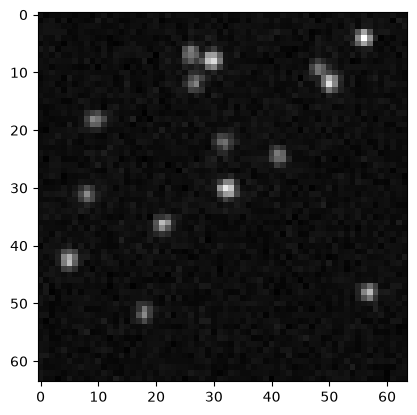

In [8]:
experimental_image = (
    fluorescence_microscope(point_emitters) + 0.1
    >> dt.Poisson(snr=15, background=0.1)
)
experimental_image.plot(cmap="gray")

Since we did not call `.update()`, the emitters keept the positions sampled in 1.2 and we only added the noise.

#### 1.4 Retrieve properties

Training also needs labels, and since we generated the image ourselves they are already stored in the properties of the scatterers. `dt.TakeProperties` collects a property across every instance of a feature, and the `&` operator stacks the image and its labels into a single pipeline, resolved from the same sample:

(-0.5, 63.5, 63.5, -0.5)

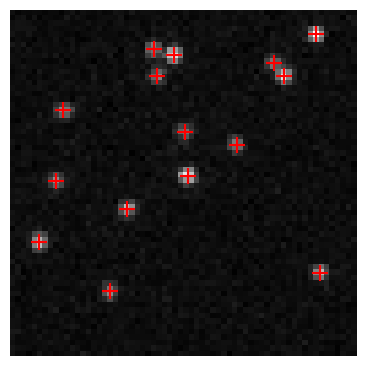

In [9]:
labelled_pipeline = experimental_image & dt.TakeProperties(experimental_image, "position")

image, *positions = labelled_pipeline()  # Resolve image and labels together.
positions = np.array(positions)

plt.figure(figsize=(4.5, 4.5))
plt.imshow(np.squeeze(image), cmap="gray")
plt.scatter(positions[:, 1], positions[:, 0], s=120, marker="+", c="r")
plt.axis("off")

Each marker sits on the particle that generated it, with sub-pixel accuracy and no manual annotation.

#### 1.5 Adding dynamics

Now we will add random motion: particles in a fluid are kicked around by the surrounding molecules and diffuse following a random walk, known as **Brownian motion**. We make a property evolve over time with `.to_sequential()`, which takes a rule computing its new value from the `previous_value`. Instead of creating new particles, we let the emitters from the previous sections diffuse for 50 frames:

In [10]:
D = 0.05  # Diffusion coefficient (um^2/s).
FRAME_TIME = 0.03  # Time between frames (s).
N_FRAMES = 50
PIXEL_SIZE_UM = 6.5 / 60  # resolution / magnification.

STEP_SIGMA_PX = np.sqrt(2 * D * FRAME_TIME) / PIXEL_SIZE_UM
print(f"Step size per frame and axis: {STEP_SIGMA_PX:.2f} px")


def brownian_step(previous_value, **kwargs):
    return previous_value + np.random.normal(0, STEP_SIGMA_PX, size=2)


# Starting point: the emitters we already generated.
starting_positions = np.array(dt.TakeProperties(point_emitters, "position")())
starting_intensities = np.array(dt.TakeProperties(point_emitters, "intensity")())

diffusing_particle = dt.PointParticle(
    position=lambda _ID: starting_positions[_ID[-1]],
    intensity=lambda _ID: starting_intensities[_ID[-1]],
).to_sequential(position=brownian_step)

diffusing_particles = diffusing_particle ^ N_PARTICLES

movie = dt.Sequence(
    fluorescence_microscope(diffusing_particles) + 0.1
    >> dt.Poisson(snr=15, background=0.1),
    sequence_length=N_FRAMES,
)

Step size per frame and axis: 0.51 px


Frames: (50, 64, 64) | Trajectories: (15, 50, 2)


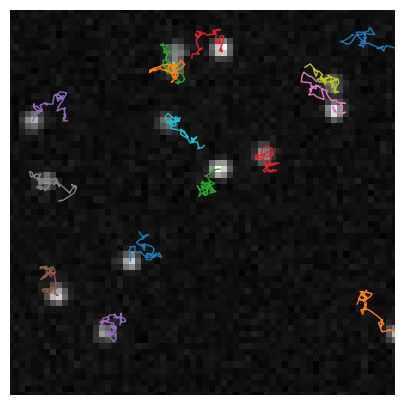

In [11]:
frames = np.array(movie.update()())[..., 0]
trajectories = np.array(dt.TakeProperties(diffusing_particles, "position")())
print("Frames:", frames.shape, "| Trajectories:", trajectories.shape)

plt.figure(figsize=(5, 5))
plt.imshow(frames[-1], cmap="gray")
for trajectory in trajectories:
    plt.plot(trajectory[:, 1], trajectory[:, 0], lw=1)
plt.xlim(0, IMAGE_SIZE - 1)
plt.ylim(IMAGE_SIZE - 1, 0)
plt.axis("off")
plt.show()

The lines are the exact path each emitter took, and they end on the particles of the last frame. These are the ground-truth trajectories a tracking algorithm would try to recover from the movie alone. Let's play it:

In [12]:
# Play the movie (it may take a few seconds to render).
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(4, 4))
frame_plot = ax.imshow(frames[0], cmap="gray", vmin=frames.min(), vmax=frames.max())
ax.axis("off")
anim = animation.FuncAnimation(
    fig, lambda t: frame_plot.set_data(frames[t]), frames=N_FRAMES, interval=50,
)
plt.close(fig)
HTML(anim.to_jshtml())

#### 1.6 Scatterers

DeepTrack2 describes every object in the sample as a **scatterer**, which defines **where** the object is (`position`, `z`) and **what shape** it has. Besides `PointParticle`, the library provides `Sphere`, `Ellipsoid` (three semi-axes and a `rotation`, good for bacteria or nuclei), and `MieSphere` / `MieStratifiedSphere`, whose scattered field is computed exactly from Mie theory.

The name comes from coherent techniques such as brightfield, where the object physically **scatters** light and the contrast comes from its `refractive_index`. In fluorescence there is no scattering: the object **emits** light, the relevant property is its `intensity`, and the refractive index is ignored. The scatterer only sets the geometry; the optics decide which physics applies.

#### 1.7 Imaging modalities

Since the scatterer and the optics are independent, the same object can be imaged with any of the five modalities that DeepTrack2 implements:

- `Fluorescence`: incoherent, the object emits light (`intensity`).
- `Brightfield`: coherent, transmitted light delayed by the object (`refractive_index`).
- `Holography`: the same propagation as brightfield, used to reconstruct the complex field.
- `ISCAT`: the scattered field interfering with a reference beam.
- `Darkfield`: only the scattered light, with the unscattered background suppressed.

All of them share the same optical parameters, so we define them once:

In [ ]:
optics_parameters = dict(
    NA=1.2,
    wavelength=630 * dt.units.nm,
    magnification=60,
    resolution=6.5 * dt.units.um,
    refractive_index_medium=1.33,
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

A `MieSphere` computes the scattered field exactly from Mie theory. In **darkfield** the unscattered illumination is removed, so the sphere appears bright on a dark background:

In [ ]:
mie_sphere = dt.MieSphere(
    position=(32, 32),
    radius=0.5 * dt.units.um,
    refractive_index=1.45,
)

darkfield_image = dt.Darkfield(**optics_parameters)(mie_sphere).resolve()

plt.figure(figsize=(4, 4))
plt.imshow(darkfield_image[..., 0], cmap="gray")
plt.title("Darkfield")
plt.axis("off")
plt.show()

In **ISCAT** the scattered field interferes with a reference beam, which produces the characteristic dark core surrounded by rings:

In [ ]:
iscat_image = dt.ISCAT(**optics_parameters)(mie_sphere).resolve()

plt.figure(figsize=(4, 4))
plt.imshow(iscat_image[..., 0], cmap="gray")
plt.title("ISCAT")
plt.axis("off")
plt.show()

Coherent modalities also accept an ordinary volume scatterer such as a `Sphere`. DeepTrack2 then warns that the field is propagated with a weak-phase approximation instead of the exact Mie solution, which is a reasonable trade-off for weakly scattering objects such as cells:

In [ ]:
sphere = dt.Sphere(
    position=(32, 32),
    radius=0.5 * dt.units.um,
    refractive_index=1.45,
)

holography_image = dt.Holography(**optics_parameters)(sphere).resolve()

plt.figure(figsize=(4, 4))
plt.imshow(holography_image[..., 0], cmap="gray")
plt.title("Holography")
plt.axis("off")
plt.show()

### Exercises

**Exercise 1. Brightfield imaging of a sphere.**

Define a `dt.Sphere` (`position`, `radius`, `refractive_index`) and image it with `dt.Brightfield` in a pipeline that also adds noise. Then play with the optical setup: what happens to the contrast as the sphere's `refractive_index` approaches `refractive_index_medium`? And when you defocus it (`z`), or change `NA` and `wavelength`?

In [ ]:
# Your code here.

**Exercise 2. A population of aberrated ellipsoids.**

Define 5 `dt.Ellipsoid` scatterers with random positions and orientations (`rotation`), image them with `dt.Fluorescence` and add noise. Then aberrate the optics with `pupil=dt.Astigmatism(coefficient=2)` and compare. Other options: `dt.SphericalAberration`, `dt.HorizontalComa`, `dt.Zernike`.

*Hint:* `radius` takes the three semi-axes, e.g. `radius=(2e-6, 0.8e-6, 0.8e-6)`, and you can build the population with `^` as in 1.2.

In [ ]:
# Your code here.

### 2. Simulating cells

Real objects are rarely perfect ellipsoids: cells have irregular outlines and visible internal structure. Since features can be composed freely, we can build such objects up step by step. Here we reproduce the stained nuclei of the [BBBC039](https://bbbc.broadinstitute.org/BBBC039) dataset, starting by looking at the real images we want to imitate together with their annotated masks:

In [ ]:
if not os.path.exists("cell_counting_dataset"):
    os.system("git clone https://github.com/DeepTrackAI/cell_counting_dataset")

root = os.path.join("cell_counting_dataset", "cell nuclei")
image_dir = os.path.join(root, "images")
mask_dir = os.path.join(root, "masks")

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

torch.Size([520, 696]) torch.Size([520, 696])


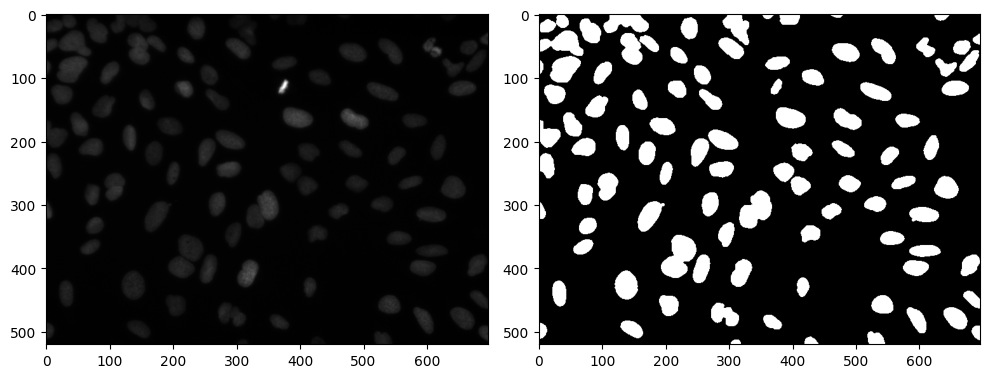

In [ ]:
def load_pair(idx):
    """Loads an image with ground truth from file."""
    image = Image.open(os.path.join(image_dir, image_files[idx]))
    image = np.array(image, dtype=np.float32)
    image = image/image.max()
    image = torch.from_numpy(image)

    mask = Image.open(os.path.join(mask_dir, mask_files[idx])).convert("RGB")
    mask = np.array(mask, np.uint8)
    mask = mask.max(axis=2)
    mask = (mask > 0).astype(np.float32)
    mask = torch.from_numpy(mask)

    return image, mask

image, mask = load_pair(0)
print(image.shape, mask.shape)

# Plot a sample.
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image, cmap="gray")
axs[1].imshow(mask, cmap="gray")
plt.tight_layout()
plt.show()

#### 2.1 Generating cell-like scatterers

To a first approximation a nucleus is an ellipsoid, so we draw its area, elongation, orientation and brightness at random. The `NA` of the microscope is randomized too, since focus and optical quality vary from one experimental image to the next:

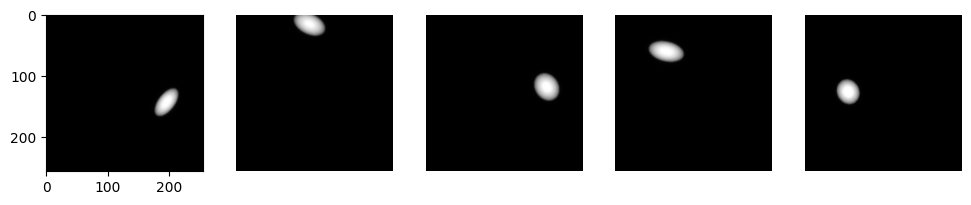

In [ ]:
IMAGE_SIZE = 256

# Helper function to keep axis within reasonable parameters.
def random_ellipse_axes():
    """Return the three axes of an ellipse."""
    ellipse_area = (np.random.uniform(3, 4)) ** 2
    radius_ratio = np.random.uniform(1, 1.5)
    major_axis = np.sqrt(ellipse_area) * radius_ratio
    minor_axis = np.sqrt(ellipse_area) / radius_ratio
    z_axis = np.sqrt(ellipse_area) * np.random.uniform(0.2, 0.4)
    return (major_axis, minor_axis, z_axis)* dt.units.um

# Define the ellipse.
ellipse = dt.Ellipsoid(
    radius = random_ellipse_axes,
    intensity=lambda: np.random.uniform(0.5, 1.5),
    position=lambda: np.random.uniform(5, IMAGE_SIZE - 5, size=2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

# Define the microscope.
optics = dt.Fluorescence(
    resolution=1e-6,
    magnification=6,
    wavelength=400e-9,
    NA=lambda: np.random.uniform(0.9, 1.1),
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

# Image the ellipses with a fluorescence microscope.
sim_im_pip = optics(ellipse)

# Plot some samples.
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axs):
    sim_im_pip.update()
    image = sim_im_pip()
    ax.imshow(image, cmap="gray")
    if i != 0: ax.axis("off")
plt.tight_layout()
plt.show()

#### 2.2 Simulating realistic cells

Plain ellipsoids are too smooth and too uniform to pass for real nuclei. Two additions close most of the gap: an **elastic transformation**, which bends the outline into something irregular, and **texture**, obtained by multiplying the nuclei with Poisson noise blurred at three different length scales. We then place them so that they do not overlap, image them, and finish by matching the background level and intensity range of the real data:

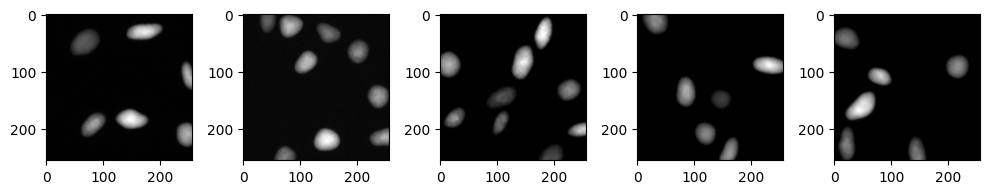

In [ ]:
ellipse = dt.Ellipsoid(
    radius = random_ellipse_axes,
    intensity=lambda: np.random.uniform(0.5, 1.5),
    position=lambda: np.random.uniform(5, IMAGE_SIZE - 5, size=2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
)

# Add elastic transformations.
synthetic_nuclei = (
    (ellipse ^ (lambda: np.random.randint(5, 10)))
    >> dt.Pad(px=(10, 10, 10, 10), keep_size=False)
    >> dt.ElasticTransformation(alpha=100, sigma=10, order=1)
    >> dt.CropTight()
)

# Define Poisson noise and Gaussian blur.
long_range_noise = (synthetic_nuclei >> dt.Poisson(snr=0.2)
                    >> dt.GaussianBlur(sigma=3.5))
short_range_noise = (synthetic_nuclei >> dt.Poisson(snr=1.0)
                     >> dt.GaussianBlur(sigma=1.5))
random_range_noise = (
    synthetic_nuclei
    >> dt.Poisson(snr=lambda: np.random.uniform(0.5, 1.5))
    >> dt.GaussianBlur(sigma=lambda: np.random.uniform(0.75, 1.5))
)

# Combine the augmentations.
noisy_synthetic_nuclei = (
    synthetic_nuclei
    * (long_range_noise + short_range_noise + random_range_noise) / 3
)

# Ensure non-overlapping cells.
non_overlap_nuclei = dt.NonOverlapping(noisy_synthetic_nuclei, min_distance=2)

# Define the microscope.
optics = dt.Fluorescence(
    resolution=1e-6, magnification=6, wavelength=400e-9,
    NA=lambda: np.random.uniform(0.9, 1.1),
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

# Define simulation pipeline with some background noise.
sim_im_pip = (optics(non_overlap_nuclei)
              >> dt.Gaussian(sigma=lambda: np.random.uniform(0, 0.1))
              >> dt.Divide(lambda: np.random.uniform(14, 20))
              >> dt.Add(lambda: np.random.uniform(-0.05, 0.15))
              >> dt.Clip(0, 1) >> dt.AsType("float"))

# Plot some samples.
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axs):
    sim_im_pip.update()
    image = sim_im_pip()
    ax.imshow(image, cmap="gray")

plt.tight_layout()
plt.show()

#### 2.3 Generating ground truth masks

The labels come for free: `dt.SampleToMasks` builds a binary mask from the very same scatterers that produced the image. We erode each nucleus slightly so that neighbours stay separated, which is what will allow us to count them as individual objects:

In [ ]:
def get_mask(radius):
    """Apply isotropic erosion to a binary mask."""
    def inner(mask):
        mask = np.sum(mask, -1, keepdims=True) > 0
        mask = np.pad(mask, [(1, 1), (1, 1), (0, 0)], mode="constant")
        mask = skmorph.isotropic_erosion(mask, radius=radius)
        return mask[1:-1, 1:-1]
    return inner

# Define mask pipeline.
sim_mask_pip = (
    noisy_synthetic_nuclei
    >> dt.SampleToMasks(get_mask, radius=2, output_region=optics.output_region,
                       merge_method="or")
    >> dt.AsType("float")
)

#### 2.4 Finalizing the training pipeline

The `&` operator pairs every image with its mask, and `dt.pytorch.Dataset` exposes the result as a standard PyTorch dataset. Samples are generated on demand and cached; `replace=0.01` regenerates a small fraction of them at each epoch, so the network keeps seeing fresh images:

In [ ]:
# Combine image simulation and mask pipeline.
sim_im_mask_pip = ((sim_im_pip & sim_mask_pip) >> dt.MoveAxis(2, 0)
                   >> dt.pytorch.ToTensor(dtype=torch.float))

# Generate the training dataset.
train_dataset = dt.pytorch.Dataset(sim_im_mask_pip, length=512, replace=0.01)

Let's sample the dataset and compare it with the real images above. The intensity histogram is a quick way to check that the simulation lands in the same range as the experimental data:

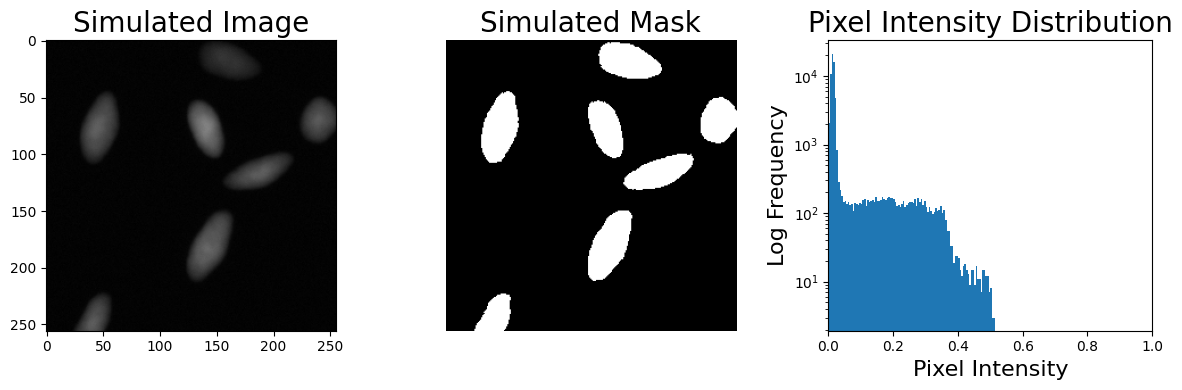

In [ ]:
sim_im, sim_mask = train_dataset[np.random.choice(len(train_dataset))]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# Plot image.
axs[0].imshow(sim_im.permute(1, 2, 0), vmin=0, vmax=1, cmap="gray")
axs[0].set_title("Simulated Image", fontsize=20)

# Plot mask.
axs[1].imshow(sim_mask.permute(1, 2, 0), vmin=0, vmax=1, cmap="gray")
axs[1].set_title("Simulated Mask", fontsize=20)
axs[1].axis("off")

# plot intensity distribution.
axs[2].hist(np.array(sim_im).flatten(), bins=200, range=(0, 1))
axs[2].set_xlabel("Pixel Intensity", fontsize=16)
axs[2].set_xlim([0, 1])
axs[2].set_ylabel("Log Frequency", fontsize=16)
axs[2].set_yscale("log")
axs[2].set_title("Pixel Intensity Distribution", fontsize=20)

plt.tight_layout()
plt.show()

### 3. Training a U-Net to count cells

A **U-Net** is a convolutional network that returns an image of the same size as its input, which makes it a natural choice to turn a microscopy image into a segmentation mask. Counting is then just a matter of labelling the connected components of that mask. The network will be trained exclusively on the images we simulated in section 2.

#### 3.1 Defining the U-Net

We build the network with [deeplay](https://github.com/DeepTrackAI/deeplay), the deep-learning companion library of DeepTrack2. The three channel sizes set how far the image is downsampled and then upsampled again. Since the network has to decide, for every pixel, whether it belongs to a nucleus or to the background, we train it with a binary cross-entropy loss:

In [ ]:
# Using deeplay U-Net template. 
model = dl.UNet2d(
    in_channels = 1,
    channels=[16, 32, 64,],
    out_channels=1,
)

# Compile as a regressor.
unet_regressor = dl.Regressor(
    model=model, loss=torch.nn.BCEWithLogitsLoss(), optimizer=dl.Adam(),
).create()

print(unet_regressor)

Regressor(
  (loss): BCEWithLogitsLoss()
  (optimizer): Adam[Adam]()
  (train_metrics): MetricCollection,
    prefix=train
  )
  (val_metrics): MetricCollection,
    prefix=val
  )
  (test_metrics): MetricCollection,
    prefix=test
  )
  (model): UNet2d(
    (encoder): ConvolutionalEncoder2d(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
      )
      (postprocess): Identity

#### 3.2 Training the U-Net

Each epoch draws batches from the simulated dataset, so the network never sees a single real image during training.

This may take a few minutes on a laptop CPU, and much less on a GPU.

c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\xlecal\Desktop\student-teacher-tracking\.venv\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | loss          | BCEWithLogitsLoss | 0      | train
1 | train_metrics | MetricCollection  | 0      | train
2 | v

Training: |          | 0/? [00:00<?, ?it/s]

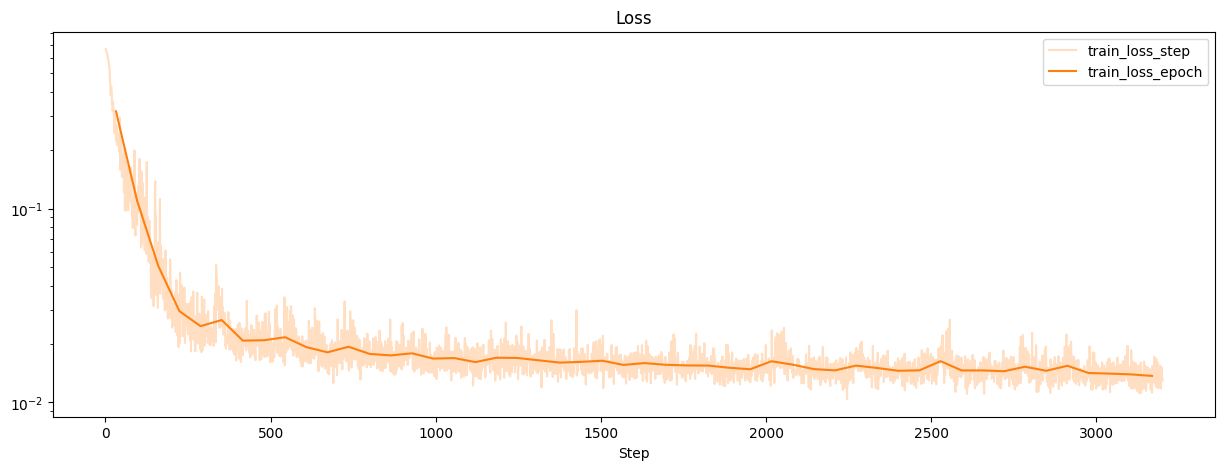

In [ ]:
# Define training data loader.
train_loader = dl.DataLoader(train_dataset, batch_size=8, shuffle=True)

# Define model trainer.
unet_trainer = dl.Trainer(max_epochs=50, accelerator="auto")

# Start training.
unet_trainer.fit(unet_regressor, train_loader) 
unet_trainer.history.plot()
unet_regressor.eval();

#### 3.3 Evaluating on real images

This is the moment of truth: we apply the network, trained **only on simulated data**, to the real BBBC039 images. For each one we threshold the predicted mask, label its connected components to obtain a cell count, and compare with the count from the annotated mask:

In [ ]:
images, masks, preds = [], [], []
with torch.no_grad():
    for idx in range(len(image_files)):
        image, mask = load_pair(idx)

        image = image.unsqueeze(0).unsqueeze(0)
        mask  = mask.unsqueeze(0).unsqueeze(0)

        pred = unet_regressor(image)
        pred = torch.sigmoid(pred).cpu()

        images.append(image.cpu())
        masks.append(mask.cpu())
        preds.append(pred)

images = torch.cat(images, dim=0)
masks  = torch.cat(masks, dim=0)
preds  = torch.cat(preds, dim=0)

true_count = np.array([skmorph.label(l.squeeze()).max() for l in masks])
pred_count = np.array([skmorph.label(p.squeeze() > .995).max() for p in preds])

mae = abs(pred_count - true_count).mean()
mpe = (abs(pred_count[true_count > 0] - true_count[true_count > 0])
       / (true_count[true_count > 0])).mean()

print(f"Mean absolute error: {mae:.2f} cells ({mpe:.1%})")

Let's look at one image, its annotation and the prediction side by side:

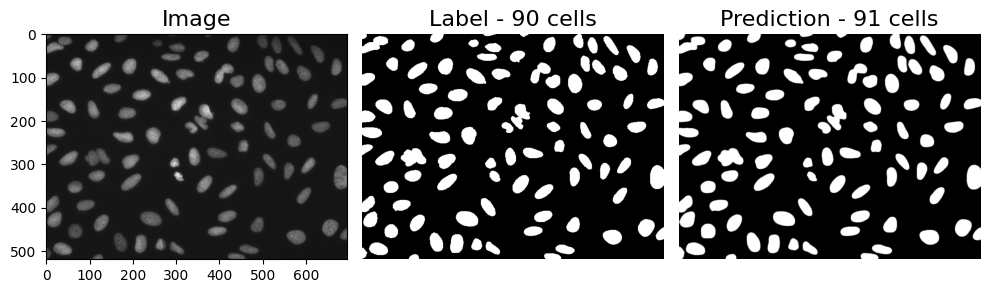

In [ ]:
random_sample = np.random.choice(len(images))

fig, axs = plt.subplots(1, 3, figsize=(10, 4))

axs[0].imshow(images[random_sample].squeeze(), vmin=0, vmax=1, cmap="gray")
axs[0].set_title("Image", fontsize=16)

axs[1].imshow(masks[random_sample].squeeze(), vmin=0, vmax=1, cmap="gray")
axs[1].set_title(f"Label - {true_count[random_sample]} cells", fontsize=16)
axs[1].axis("off")

axs[2].imshow(preds[random_sample].squeeze(), cmap="gray")
axs[2].set_title(f"Prediction - {pred_count[random_sample]} cells", fontsize=16)
axs[2].axis("off")

plt.tight_layout()
plt.show()

**Exercise 3.** Plot the predicted cell counts against the true counts for the whole dataset. Is the error uniform, or does the network struggle more on the crowded images?

In [ ]:
# Your code here.


**Exercise 4.** Pick one aspect of the simulation and change it in 2.2: the number of nuclei per image, the amount of texture and noise, the range of sizes in `random_ellipse_axes`, or the background level. Regenerate the dataset, retrain the U-Net and compare the error on the real images with the one you obtained above. Which change hurts the most?

In [ ]:
# Your code here.


### 4. Discussion

We went from a single point emitter to a network that counts real cells, without annotating a single image. The pipeline was the same throughout:

**scatterer → optics → noise → image + ground truth**

Only the scatterer and the optical device changed along the way.

**Which simulation choices mattered?** Compare what you found in Exercise 4 with the rest of the group. Some parameters barely affect the result, while others break the model as soon as they stop matching the real data. A useful rule of thumb is that the simulation does not need to be beautiful, but it does need to **cover** the variability of the real images: when in doubt, randomize a parameter over a wider range than you expect to encounter.

**Could you build this for your own problem?** The recipe transfers directly: describe your object as a scatterer, or write your own if none of the built-in shapes fits, pick the optical device matching your microscope, match the pixel size, and reproduce the noise of your camera.

**When is simulated data a reasonable substitute for annotated data?** It works best when the imaging physics is well understood, the objects can be described with a handful of parameters, and annotation is slow, unreliable or outright impossible, as with sub-pixel positions or dense 3D samples. It gets harder when the appearance of the objects is too complex to model, although even then a simulated dataset is often a good starting point to pre-train a model before fine-tuning it on a few annotated images.